# DSA 210 — ML Phase: Day 3
## Tree Ensemble Models

**Bedirhan Ceylan** — Spring 2026

Day 2 baselines maxed out around ROC-AUC 0.71 (kNN). Day 3 trains two tree ensembles — Random Forest and Gradient Boosting — to capture feature interactions that linear and distance-based models miss. Same evaluation protocol: stratified 5-fold CV plus an 80/20 held-out test split.

## 1. Setup & Load Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

data = pd.read_csv('../data/sollen_tasks_features.csv')
print(f"Loaded: {data.shape[0]} rows, {data.shape[1]} columns")

Loaded: 486 rows, 11 columns


## 2. Features, Target, and Preprocessing

In [2]:
y = data['is_delayed']
X = data.drop(columns=['is_delayed'])

categorical_features = ['task_category', 'assigned_to', 'creation_day']
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

print(f"Categorical: {categorical_features}")
print(f"Numeric: {numeric_features}")
print(f"Class balance — delayed: {y.sum()} ({y.mean()*100:.1f}%) | on_time: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

Categorical: ['task_category', 'assigned_to', 'creation_day']
Numeric: ['creation_month_num', 'is_weekend_creation', 'title_word_count', 'team_total_load_at_creation', 'developer_workload_at_creation', 'dev_historical_delay_rate', 'dev_avg_past_duration']
Class balance — delayed: 169 (34.8%) | on_time: 317 (65.2%)


## 3. Define Tree Ensemble Models

- **Random Forest** — 200 trees, depth-limited to 8, `class_weight='balanced'` for imbalance
- **Gradient Boosting** — 200 boosting stages, learning rate 0.05, depth 3 (sklearn's GBM does not accept `class_weight`; the imbalance is handled implicitly via the loss function)

For a complete comparison, we re-include the three Day 2 baselines so all five models appear on the same plots.

In [3]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                                    random_state=42)
}

pipelines = {name: Pipeline([('prep', preprocessor), ('clf', model)])
             for name, model in models.items()}

print(f"Built {len(pipelines)} pipelines:")
for name in pipelines:
    print(f"  - {name}")

Built 5 pipelines:
  - Logistic Regression
  - Decision Tree
  - kNN (k=5)
  - Random Forest
  - Gradient Boosting


## 4. Stratified 5-Fold Cross-Validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = []
metric_means = {name: {} for name in pipelines}

for name, pipe in pipelines.items():
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        row[metric] = f"{scores.mean():.3f} ± {scores.std():.3f}"
        metric_means[name][metric] = scores.mean()
    results.append(row)

results_df = pd.DataFrame(results).set_index('Model')
print("Cross-validation results (mean ± std across 5 folds):\n")
print(results_df.to_string())

Cross-validation results (mean ± std across 5 folds):

                          accuracy      precision         recall             f1        roc_auc
Model                                                                                         
Logistic Regression  0.553 ± 0.048  0.407 ± 0.035  0.592 ± 0.031  0.481 ± 0.023  0.577 ± 0.039
Decision Tree        0.562 ± 0.034  0.389 ± 0.035  0.498 ± 0.179  0.422 ± 0.109  0.582 ± 0.030
kNN (k=5)            0.673 ± 0.033  0.538 ± 0.048  0.398 ± 0.154  0.445 ± 0.100  0.662 ± 0.050
Random Forest        0.673 ± 0.015  0.534 ± 0.024  0.498 ± 0.084  0.511 ± 0.041  0.706 ± 0.040
Gradient Boosting    0.661 ± 0.022  0.514 ± 0.048  0.367 ± 0.074  0.426 ± 0.064  0.684 ± 0.033


## 5. Visualize CV — All Five Models

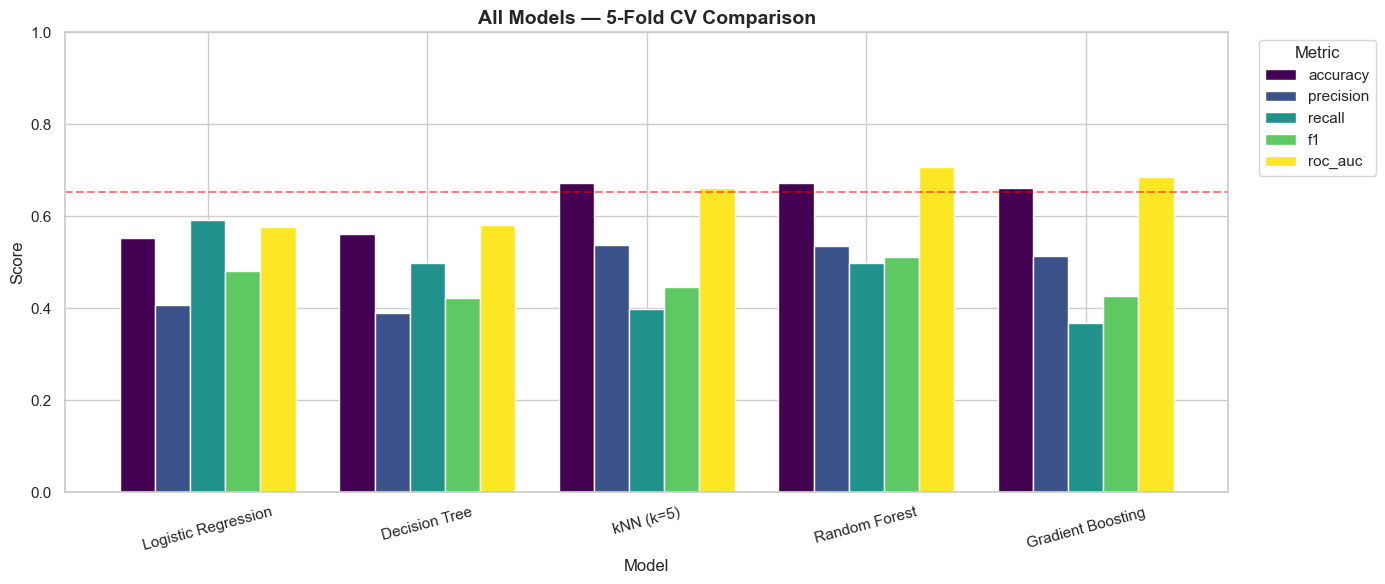

In [5]:
plot_df = pd.DataFrame(metric_means).T

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')
ax.set_title('All Models — 5-Fold CV Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=0.652, color='red', linestyle='--', alpha=0.5, label='Majority baseline')
plt.tight_layout()
plt.savefig('../plots/15_all_models_cv_comparison.png', bbox_inches='tight')
plt.show()

## 6. Train/Test Split — Detailed Evaluation

Same 80/20 stratified split as Day 2 (random_state=42) so results are directly comparable.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% delayed)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% delayed)\n")

trained = {}
test_aucs = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    test_aucs[name] = auc

# Detailed report only for the two new models
for name in ['Random Forest', 'Gradient Boosting']:
    pipe = trained[name]
    y_pred = pipe.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['on_time', 'delayed']))
    print(f"Test ROC-AUC: {test_aucs[name]:.3f}\n")

print("--- Test ROC-AUC summary (all models) ---")
for name, auc in sorted(test_aucs.items(), key=lambda x: -x[1]):
    print(f"  {name:25s}  {auc:.3f}")

Train: 388 samples (34.8% delayed)
Test:  98 samples (34.7% delayed)

--- Random Forest ---
              precision    recall  f1-score   support

     on_time       0.76      0.83      0.79        64
     delayed       0.61      0.50      0.55        34

    accuracy                           0.71        98
   macro avg       0.68      0.66      0.67        98
weighted avg       0.71      0.71      0.71        98

Test ROC-AUC: 0.741

--- Gradient Boosting ---
              precision    recall  f1-score   support

     on_time       0.73      0.89      0.80        64
     delayed       0.65      0.38      0.48        34

    accuracy                           0.71        98
   macro avg       0.69      0.64      0.64        98
weighted avg       0.70      0.71      0.69        98

Test ROC-AUC: 0.725

--- Test ROC-AUC summary (all models) ---
  Random Forest              0.741
  Gradient Boosting          0.725
  kNN (k=5)                  0.710
  Logistic Regression        0.639
  De

## 7. Confusion Matrices — Tree Ensembles

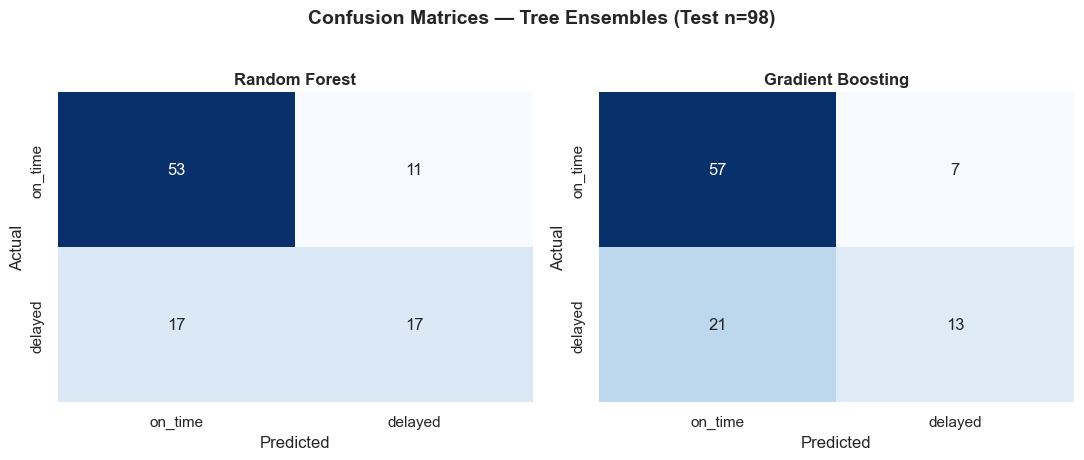

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    y_pred = trained[name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['on_time', 'delayed'], yticklabels=['on_time', 'delayed'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Tree Ensembles (Test n=98)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/16_ensemble_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8. ROC Curves — All Five Models

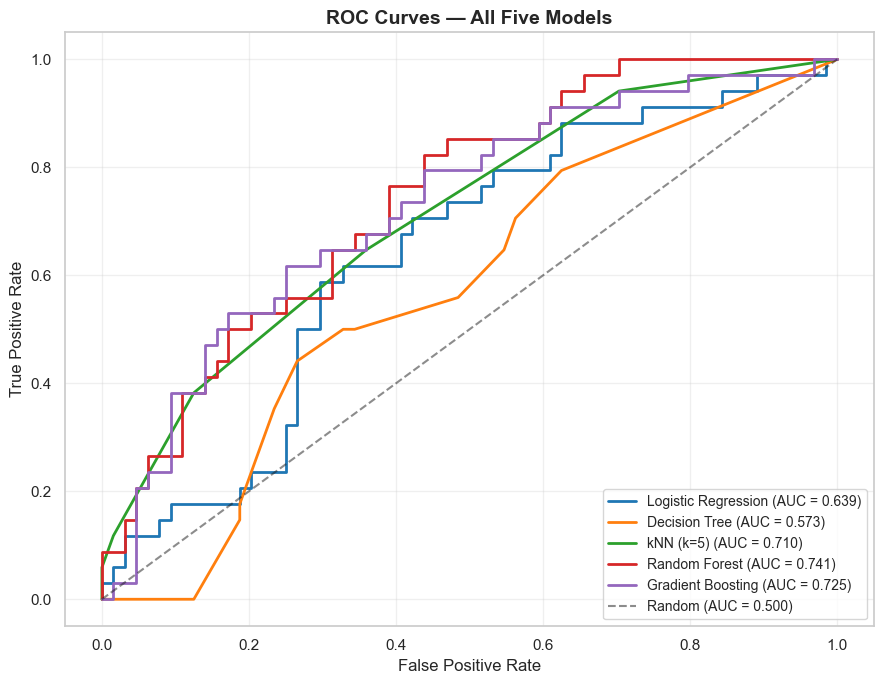

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, pipe), color in zip(trained.items(), colors):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = test_aucs[name]
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Five Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/17_all_models_roc_curves.png', bbox_inches='tight')
plt.show()

## 9. Feature Importance

Random Forest and Gradient Boosting expose feature importances directly. We extract them from each fitted model and rank the top contributors. Note: one-hot encoding inflates the feature count (one column per category level), so importances for `task_category`, `assigned_to`, and `creation_day` are spread across multiple sub-features.

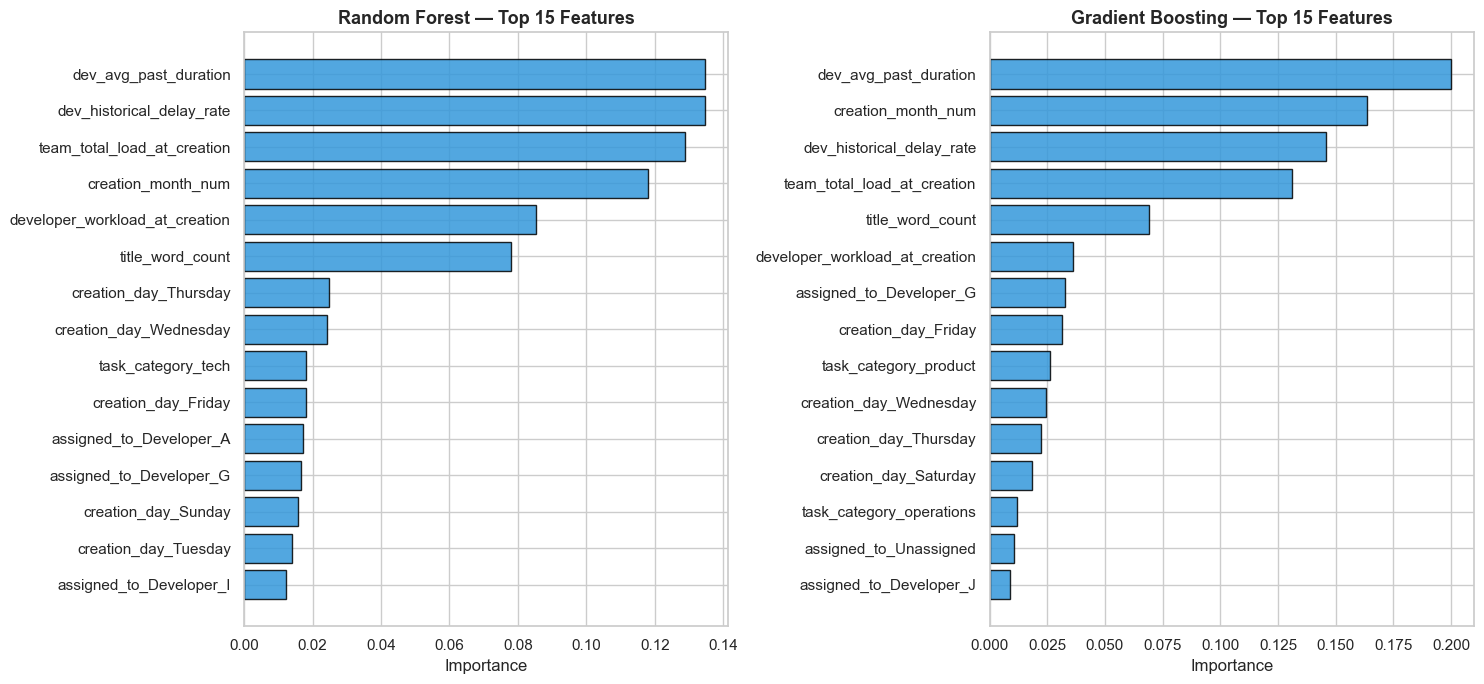

In [9]:
def get_feature_names(pipe):
    prep = pipe.named_steps['prep']
    cat_names = prep.named_transformers_['cat'].get_feature_names_out(categorical_features)
    return list(cat_names) + numeric_features

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    pipe = trained[name]
    importances = pipe.named_steps['clf'].feature_importances_
    feature_names = get_feature_names(pipe)

    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=True).tail(15)

    ax.barh(imp_df['feature'], imp_df['importance'], color='#3498db', alpha=0.85, edgecolor='black')
    ax.set_title(f'{name} — Top 15 Features', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../plots/18_feature_importance.png', bbox_inches='tight')
plt.show()

## 10. Aggregated Feature Importance

To make the picture cleaner, we sum the one-hot sub-feature importances back to the original feature level. This shows which **engineered feature** is actually doing the work, regardless of how many one-hot columns it produced.

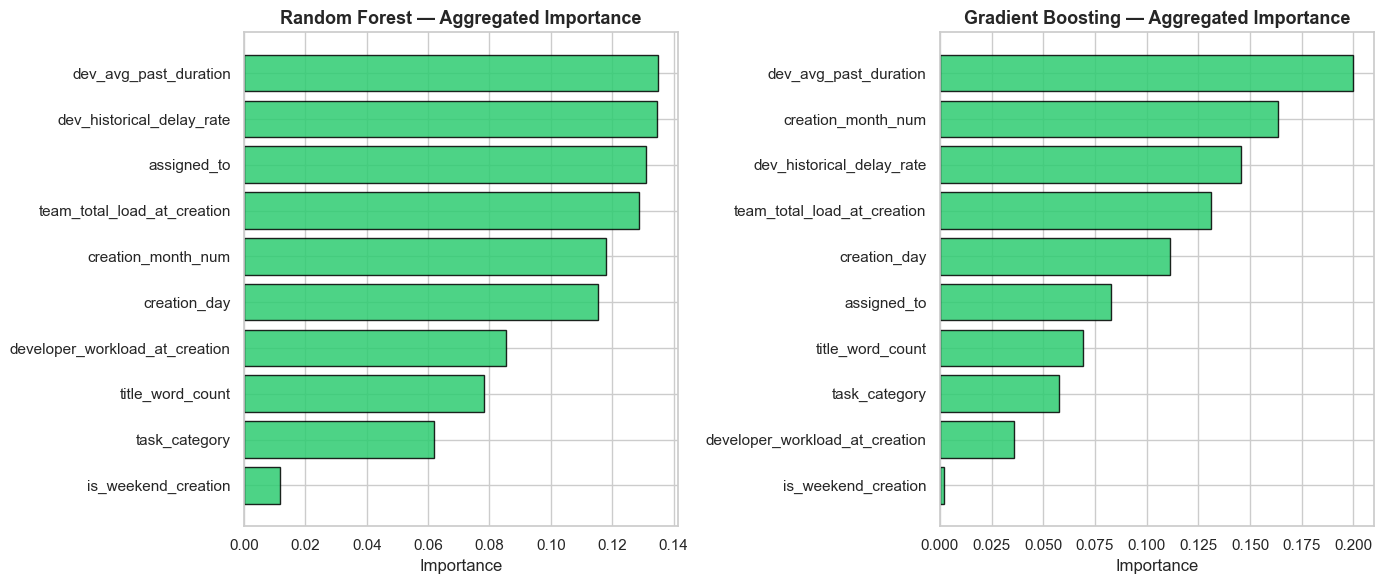


Random Forest — aggregated ranking:
dev_avg_past_duration             0.135
dev_historical_delay_rate         0.135
assigned_to                       0.131
team_total_load_at_creation       0.129
creation_month_num                0.118
creation_day                      0.115
developer_workload_at_creation    0.085
title_word_count                  0.078
task_category                     0.062
is_weekend_creation               0.012
dtype: float64

Gradient Boosting — aggregated ranking:
dev_avg_past_duration             0.200
creation_month_num                0.164
dev_historical_delay_rate         0.146
team_total_load_at_creation       0.131
creation_day                      0.111
assigned_to                       0.083
title_word_count                  0.069
task_category                     0.058
developer_workload_at_creation    0.036
is_weekend_creation               0.002
dtype: float64


In [10]:
def aggregate_importances(pipe):
    importances = pipe.named_steps['clf'].feature_importances_
    feature_names = get_feature_names(pipe)
    agg = {col: 0.0 for col in X.columns}
    for fname, imp in zip(feature_names, importances):
        # categorical sub-features have form 'task_category_tech' etc.
        matched = False
        for orig in categorical_features:
            if fname.startswith(orig + '_'):
                agg[orig] += imp
                matched = True
                break
        if not matched:
            agg[fname] += imp
    return pd.Series(agg).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    agg = aggregate_importances(trained[name])
    ax.barh(agg.index, agg.values, color='#2ecc71', alpha=0.85, edgecolor='black')
    ax.set_title(f'{name} — Aggregated Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../plots/19_feature_importance_aggregated.png', bbox_inches='tight')
plt.show()

print("\nRandom Forest — aggregated ranking:")
print(aggregate_importances(trained['Random Forest']).sort_values(ascending=False).round(3))
print("\nGradient Boosting — aggregated ranking:")
print(aggregate_importances(trained['Gradient Boosting']).sort_values(ascending=False).round(3))

## Day 3 Summary

- Trained Random Forest (200 trees, depth 8) and Gradient Boosting (200 stages, lr=0.05, depth 3)
- Re-evaluated all five models with stratified 5-fold CV on the same metrics
- Generated confusion matrices, ROC curves, and feature importance plots
- Aggregated one-hot importances back to original features for interpretability
- Saved 5 new plots (`15_` through `19_`)

**Next (Day 4):** Final model selection, README update, requirements freeze, and prep for May 5 push.